In [1]:
from pprint import pprint
from pathlib import Path
from codebase.knowledgebase import NERKnowledgeBase

In [2]:
kb_path = Path("./knowledge_base/kb.json")
if kb_path.exists():
    kb = NERKnowledgeBase.load(kb_path)
    print("KnowledgeBase loaded from kb.json")
else:
    kb = NERKnowledgeBase()
    print("Initialized empty KnowledgeBase")

KnowledgeBase loaded from kb.json


### Explore KB content

In [3]:
print("Categories in KB:", list(kb.categories.keys()))

# Example: list first 10 entities of a category
for cat, entities in kb.categories.items():
    print(f"\nCategory: {cat}")
    print(list(entities)[:10])

Categories in KB: ['geo', 'gpe', 'per', 'org', 'tim', 'art', 'nat', 'eve']

Category: geo
['eastern Sudan', 'Federline', 'Buenos Aires', 'Zamfara', 'Mohsen Tasalouti', 'Gulf', 'Hawaii Marine', 'Adelie Land', 'Galle', 'Malegaon']

Category: gpe
['Lithuanian', 'Jordanians', 'Kyrgyzstan', 'Ugandans', 'Liberian', 'Panamanians', 'Damascus', 'Tokyo', 'Principality of Muscovy', 'Mali']

Category: per
['Kim Kye Kwan', 'Faisal Fayez', 'Vice President Parviz Davoodi', 'Viktoria Volchkova', 'Moore', 'Senator Clinton', 'Chen Hualan', 'Shaima Rezayee', 'Van Schalkwyk', 'Vice President Zeng Qinghong']

Category: org
['LBC', 'The OECD', 'Emirates airlines', 'Tareq al-Hashemi', 'Buenos Aires', 'Nobel Laureate', 'VOA Producer', 'Jac et le Takeifa', 'Future of Kosovo', 'Court of Appeal']

Category: tim
['June 11 and July 11', 'Gunbattles', 'mid-afternoon yesterday', '1848', '12', 'between 1996 and 2001', 'or two', 'Prachanda', '13th - 15th', '1989 Taif']

Category: art
['Blades Of Glory', 'U.N. World Fo

### Add new entities manually

In [4]:
kb.add_entity("Natalia Marine Infantry", "per", texts=["Natalia Marine Infantry, I'm going to get behind the wheel now, and you're get out of here!"], meaning="Name of the person from a famous Russian meme.")
kb.add_entity("Debily", "org", texts=["\"Debily\" is the most widespread organization in the world - they have their people everywhere."], meaning="Most-known organization.")

pprint(kb.get_entity_info("Natalia Marine Infantry"))
pprint(kb.get_entity_info("Debily"))

{'categories': ['per'],
 'meaning': 'Name of the person from a famous Russian meme.',
 'texts': ["Natalia Marine Infantry, I'm going to get behind the wheel now, "
           "and you're get out of here!"]}
{'categories': ['org'],
 'meaning': 'Most-known organization.',
 'texts': ['"Debily" is the most widespread organization in the world - they '
           'have their people everywhere.']}


### Delete entities manually

In [5]:
kb.delete_entity("Debily")
pprint(kb.get_entity_info("Debily"))

{'categories': [], 'meaning': '', 'texts': []}


### Add a category and reassign entities

In [6]:
kb.add_category("memes", entities=["Natalia Marine Infantry"], reassign=True)
pprint(kb.get_entity_info("Natalia Marine Infantry"))


{'categories': ['memes'],
 'meaning': 'Name of the person from a famous Russian meme.',
 'texts': ["Natalia Marine Infantry, I'm going to get behind the wheel now, "
           "and you're get out of here!"]}


### Populate from input text with NER model predictions

In [ ]:
from codebase.model.inference import run_inference

input_sentences = [
    "Does the name Ibrahim mean anything to you ?"
]

sentences, word_predictions = run_inference(
    checkpoint_dir="./checkpoints/bert-ner-large/checkpoint-4320",
    input_data=input_sentences,
)

pprint(sentences)
pprint(word_predictions)

kb.add_entities_from_model(sentences, word_predictions)

pprint(kb.get_entity_info("Ibrahim"))

/home/owmtgf/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Running inference: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]


[['Does', 'the', 'name', 'Ibrahim', 'mean', 'anything', 'to', 'you', '?']]
[[0, 0, 0, 1, 0, 0, 0, 0, 0]]


Populating KB from model: 1it [00:00, 8867.45it/s]

{'categories': ['per'],
 'meaning': '',
 'texts': ['The government has offered a reward of $ 2,50,000 for information '
           'leading to the capture of JEM leader Ibrahim .',
           'Does the name Ibrahim mean anything to you ?']}


### Highlight important words when inference

In [8]:
kb.highlight_sentence(sentences[0], word_predictions[0])

### Show a Word-Cloud map for certain category

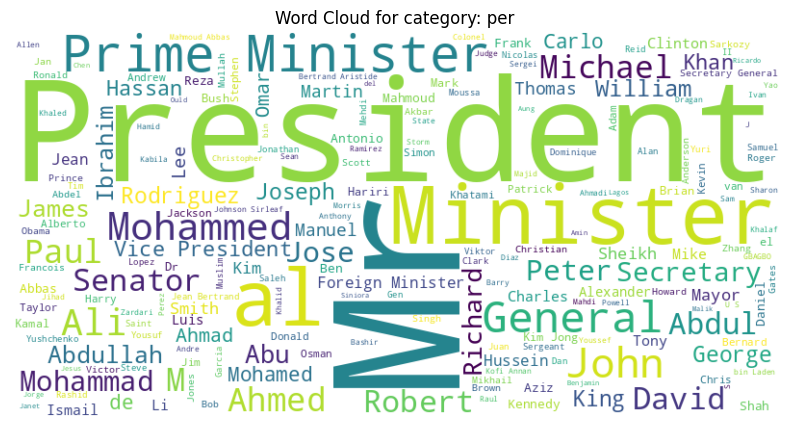

In [9]:
kb.plot_wordcloud("per")